# EDA - Camada Bronze: DATASUS (`dados_DATASUS`)

Análise exploratória dos quatro Parquet gerados por [extracao_bronze_datasus.ipynb](extracao_bronze_datasus.ipynb) — duas métricas hospitalares (SIH/SUS: `aih_aprovadas`, `valor_total`) e duas ambulatoriais (SIA/SUS: `qtd_aprovada`, `valor_aprovado`).

Mesmo objetivo das EDAs anteriores ([exploracao_bronze_isaps.ipynb](exploracao_bronze_isaps.ipynb), [exploracao_bronze_ibge.ipynb](exploracao_bronze_ibge.ipynb)): mapear o que a Silver precisa resolver, não produzir a análise final. As quatro tabelas ficam separadas durante toda a EDA — são métricas diferentes (contagem x valor monetário) sobre dois sistemas diferentes (hospitalar x ambulatorial).

## 1. Imports e configuração

In [1]:
import os

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)

BRONZE_DIR = os.path.join('..', 'dados_processados', 'bronze', 'dados_DATASUS')

## 2. Carregamento dos arquivos bronze

Quatro DataFrames separados — `aih` e `valor_hosp` (hospitalar, SIH/SUS), `qtd_amb` e `valor_amb` (ambulatorial, SIA/SUS) — pela mesma razão de sempre: são recortes diferentes do mesmo domínio (procedimentos do SUS), não linhas da mesma tabela.

In [2]:
aih = pd.read_parquet(os.path.join(BRONZE_DIR, 'aih_aprovadas_procedimentos_hospitalares.parquet'))
valor_hosp = pd.read_parquet(os.path.join(BRONZE_DIR, 'valor_total_procedimentos_hospitalares.parquet'))
qtd_amb = pd.read_parquet(os.path.join(BRONZE_DIR, 'qtd_aprovada_producao_ambulatorial.parquet'))
valor_amb = pd.read_parquet(os.path.join(BRONZE_DIR, 'valor_aprovado_producao_ambulatorial.parquet'))

TABELAS = {'aih': aih, 'valor_hosp': valor_hosp, 'qtd_amb': qtd_amb, 'valor_amb': valor_amb}
for nome, df in TABELAS.items():
    print(f'{nome}: {df.shape}')

aih: (32094, 11)
valor_hosp: (32094, 11)
qtd_amb: (33876, 11)
valor_amb: (26604, 11)


## 3. Visão geral de cada dataset

Confere colunas, tipos e as primeiras/últimas linhas — sanidade básica antes de qualquer análise.

In [3]:
aih.dtypes

arquivo_origem               str
categoria                    str
metrica                      str
titulo                       str
descricao_variavel           str
periodo_relatorio            str
procedimento_original        str
procedimento_codigo          str
procedimento_nome            str
ano                        int64
quantidade               float64
dtype: object

In [4]:
aih.head()

,arquivo_origem,categoria,metrica,titulo,descricao_variavel,periodo_relatorio,procedimento_original,procedimento_codigo,procedimento_nome,ano,quantidade
0,AIH-aprovadas_Procedimentos-hospitalares.csv,hospitalar,aih_aprovadas,Procedimentos hospitalares do SUS - por local ...,AIH aprovadas por Procedimento e Ano atendimento,Período:2014-2024,0201010038 BIOPSIA CIRURGICA DE TIREOIDE,0201010038,BIOPSIA CIRURGICA DE TIREOIDE,2007,NaN
1,AIH-aprovadas_Procedimentos-hospitalares.csv,hospitalar,aih_aprovadas,Procedimentos hospitalares do SUS - por local ...,AIH aprovadas por Procedimento e Ano atendimento,Período:2014-2024,0201010038 BIOPSIA CIRURGICA DE TIREOIDE,0201010038,BIOPSIA CIRURGICA DE TIREOIDE,2008,NaN
2,AIH-aprovadas_Procedimentos-hospitalares.csv,hospitalar,aih_aprovadas,Procedimentos hospitalares do SUS - por local ...,AIH aprovadas por Procedimento e Ano atendimento,Período:2014-2024,0201010038 BIOPSIA CIRURGICA DE TIREOIDE,0201010038,BIOPSIA CIRURGICA DE TIREOIDE,2009,NaN
3,AIH-aprovadas_Procedimentos-hospitalares.csv,hospitalar,aih_aprovadas,Procedimentos hospitalares do SUS - por local ...,AIH aprovadas por Procedimento e Ano atendimento,Período:2014-2024,0201010038 BIOPSIA CIRURGICA DE TIREOIDE,0201010038,BIOPSIA CIRURGICA DE TIREOIDE,2010,NaN
4,AIH-aprovadas_Procedimentos-hospitalares.csv,hospitalar,aih_aprovadas,Procedimentos hospitalares do SUS - por local ...,AIH aprovadas por Procedimento e Ano atendimento,Período:2014-2024,0201010038 BIOPSIA CIRURGICA DE TIREOIDE,0201010038,BIOPSIA CIRURGICA DE TIREOIDE,2011,NaN


In [5]:
aih.tail()

,arquivo_origem,categoria,metrica,titulo,descricao_variavel,periodo_relatorio,procedimento_original,procedimento_codigo,procedimento_nome,ano,quantidade
32089,AIH-aprovadas_Procedimentos-hospitalares.csv,hospitalar,aih_aprovadas,Procedimentos hospitalares do SUS - por local ...,AIH aprovadas por Procedimento e Ano atendimento,Período:2014-2024,Total,NaN,Total,2020,10634389.0
32090,AIH-aprovadas_Procedimentos-hospitalares.csv,hospitalar,aih_aprovadas,Procedimentos hospitalares do SUS - por local ...,AIH aprovadas por Procedimento e Ano atendimento,Período:2014-2024,Total,NaN,Total,2021,11670527.0
32091,AIH-aprovadas_Procedimentos-hospitalares.csv,hospitalar,aih_aprovadas,Procedimentos hospitalares do SUS - por local ...,AIH aprovadas por Procedimento e Ano atendimento,Período:2014-2024,Total,NaN,Total,2022,12467808.0
32092,AIH-aprovadas_Procedimentos-hospitalares.csv,hospitalar,aih_aprovadas,Procedimentos hospitalares do SUS - por local ...,AIH aprovadas por Procedimento e Ano atendimento,Período:2014-2024,Total,NaN,Total,2023,13331354.0
32093,AIH-aprovadas_Procedimentos-hospitalares.csv,hospitalar,aih_aprovadas,Procedimentos hospitalares do SUS - por local ...,AIH aprovadas por Procedimento e Ano atendimento,Período:2014-2024,Total,NaN,Total,2024,13335211.0


## 4. Qualidade dos dados

**Nulos em `procedimento_codigo`:** só a linha `Total` deveria ter `procedimento_codigo` nulo — uma por ano. Conferir que a contagem de nulos bate exatamente com a quantidade de anos de cada tabela é a prova de que nenhuma outra linha ficou sem código por engano na extração.

In [6]:
for nome, df in TABELAS.items():
    n_nulos = df['procedimento_codigo'].isnull().sum()
    n_anos = df['ano'].nunique()
    print(f'{nome}: nulos_codigo={n_nulos} | anos={n_anos} | bate={n_nulos == n_anos}')

aih: nulos_codigo=18 | anos=18 | bate=True
valor_hosp: nulos_codigo=18 | anos=18 | bate=True
qtd_amb: nulos_codigo=12 | anos=12 | bate=True
valor_amb: nulos_codigo=12 | anos=12 | bate=True


**Nulos em `quantidade` — bem mais frequentes aqui do que no ISAPS ou no IBGE, e por um motivo estrutural, não aleatório.** Olhando só o total por tabela já dá pra ver que a taxa é alta (10-35%); a causa fica clara ao olhar por ano (célula seguinte).

In [7]:
for nome, df in TABELAS.items():
    pct = df['quantidade'].isnull().mean() * 100
    print(f'{nome}: {df["quantidade"].isnull().sum()} nulos ({pct:.1f}%)')

aih: 11389 nulos (35.5%)
valor_hosp: 11389 nulos (35.5%)
qtd_amb: 4689 nulos (13.8%)
valor_amb: 3079 nulos (11.6%)


**Nulos por ano (achado principal para a Silver):** a tabela `aih` tem **99%+ de nulos** em `quantidade` nos anos 2007 a 2012, cai para 10% em 2013, e estabiliza entre 2-4% a partir de 2014 — o mesmo patamar dos anos "normais". Isso não é uma falha de extração: o próprio relatório declara `periodo_relatorio = "Período:2014-2024"` (célula seguinte confirma), ou seja, **2014-2024 é o período que foi efetivamente solicitado**; o TabNet incluiu de brinde as colunas de 2007-2013, que na prática estão quase todas vazias — sinal de que a classificação de procedimentos usada nesta tabela só passou a ser usada de forma consistente a partir de 2013/2014 (a linha `Total` também mostra um salto de ~56 mil em 2012 para 778 mil em 2013 e mais de 11 milhões a partir de 2014, confirmando a mudança de patamar). A recomendação para a Silver é **não tratar os nulos de 2007-2012 como "procedimento não realizado"** da mesma forma que os nulos de 2014 em diante — são duas situações diferentes: um é ausência real de dado num período em que a série mal existe, o outro é a ausência normal de uma série madura.

In [8]:
nulos_por_ano = aih[aih['procedimento_codigo'].notnull()].groupby('ano')['quantidade'].apply(lambda s: round(s.isnull().mean() * 100, 1))
print('periodo_relatorio (declarado no proprio CSV):', aih['periodo_relatorio'].iloc[0])
nulos_por_ano

periodo_relatorio (declarado no proprio CSV): Período:2014-2024


ano
2007    99.9
2008    99.6
2009    99.6
2010    99.6
2011    99.4
2012    99.4
2013    10.0
2014     3.6
2015     3.9
2016     4.0
2017     2.9
2018     2.4
2019     2.3
2020     2.6
2021     2.9
2022     2.6
2023     2.0
2024     2.4
Name: quantidade, dtype: float64

**Duplicados:** confere que nenhuma linha é totalmente repetida em nenhuma das quatro tabelas.

In [9]:
for nome, df in TABELAS.items():
    print(f'{nome}: duplicadas={df.duplicated().sum()}')

aih: duplicadas=0
valor_hosp: duplicadas=0
qtd_amb: duplicadas=0
valor_amb: duplicadas=0


## 5. Estatísticas descritivas

`aih`/`qtd_amb` são contagens (unidade: número de procedimentos); `valor_hosp`/`valor_amb` são valores em reais — escalas bem diferentes, então cada uma é olhada separadamente.

In [10]:
aih['quantidade'].describe()

count    2.070500e+04
mean     1.286423e+04
std      2.793462e+05
min      1.000000e+00
25%      5.500000e+01
50%      2.840000e+02
75%      1.514000e+03
max      1.333521e+07
Name: quantidade, dtype: float64

In [11]:
valor_hosp['quantidade'].describe()

count    2.070500e+04
mean     1.823488e+07
std      4.043759e+08
min      6.216000e+01
25%      9.118696e+04
50%      4.895033e+05
75%      2.432192e+06
max      2.229394e+10
Name: quantidade, dtype: float64

In [12]:
qtd_amb['quantidade'].describe()

count    2.918700e+04
mean     2.988827e+06
std      7.798165e+07
min      1.000000e+00
25%      1.061000e+03
50%      1.210500e+04
75%      1.852320e+05
max      4.903599e+09
Name: quantidade, dtype: float64

In [13]:
valor_amb['quantidade'].describe()

count    2.352500e+04
mean     2.027263e+07
std      4.850873e+08
min      1.000000e-02
25%      2.860000e+04
50%      3.474093e+05
75%      3.075200e+06
max      3.203706e+10
Name: quantidade, dtype: float64

## 6. Dimensões categóricas

Quantidade de procedimentos distintos e de anos cobertos por tabela — dimensiona o tamanho de cada dataset e mostra que hospitalar (2007-2024) e ambulatorial (2013-2024) não cobrem o mesmo intervalo de anos.

In [14]:
for nome, df in TABELAS.items():
    n_proc = df['procedimento_codigo'].nunique()
    anos = sorted(df['ano'].unique())
    print(f'{nome}: {n_proc} procedimentos | anos {anos[0]}-{anos[-1]} ({len(anos)} anos)')

aih: 1782 procedimentos | anos 2007-2024 (18 anos)
valor_hosp: 1782 procedimentos | anos 2007-2024 (18 anos)
qtd_amb: 2822 procedimentos | anos 2013-2024 (12 anos)
valor_amb: 2216 procedimentos | anos 2013-2024 (12 anos)


## 7. Consistência cruzada entre as tabelas (achado importante para a Silver)

`aih` e `valor_hosp` vêm do mesmo sistema (SIH/SUS) e deveriam cobrir exatamente o mesmo conjunto de procedimentos — e cobrem: os dois `set()` de `procedimento_codigo` são idênticos. Já `qtd_amb` e `valor_amb` (SIA/SUS) **não batem**: existem procedimentos que aparecem em `qtd_amb` mas nunca aparecem como linha em `valor_amb` — não é um valor zerado, a linha simplesmente não existe nesse segundo arquivo. Isso é um risco concreto de **junção** para quem for cruzar as duas tabelas de ambulatorial na Silver ou na Gold: um `merge` ingênuo por `procedimento_codigo` descartaria (ou geraria nulo para) esses procedimentos do lado de `valor_amb`, mesmo eles tendo quantidade registrada. Os exemplos abaixo (sessão de antroposofia, um medicamento específico, um item de manutenção de dispositivo) sugerem que são procedimentos aprovados em quantidade mas sem custo/repasse associado — mas isso é uma hipótese, não uma certeza; fica registrado para quem for tratar a Silver decidir como representar esse caso (nulo explícito vs. exclusão), em vez de a lacuna aparecer sem explicação depois de um `merge`.

In [15]:
codigos_aih = set(aih['procedimento_codigo'].dropna())
codigos_valor_hosp = set(valor_hosp['procedimento_codigo'].dropna())
print(f'hospitalar: aih={len(codigos_aih)} | valor_hosp={len(codigos_valor_hosp)} | diferenca={len(codigos_aih ^ codigos_valor_hosp)}')

codigos_qtd_amb = set(qtd_amb['procedimento_codigo'].dropna())
codigos_valor_amb = set(valor_amb['procedimento_codigo'].dropna())
so_em_qtd = codigos_qtd_amb - codigos_valor_amb
print(f'ambulatorial: qtd_amb={len(codigos_qtd_amb)} | valor_amb={len(codigos_valor_amb)} | so em qtd_amb={len(so_em_qtd)}')

hospitalar: aih=1782 | valor_hosp=1782 | diferenca=0


ambulatorial: qtd_amb=2822 | valor_amb=2216 | so em qtd_amb=606


In [16]:
amostra = qtd_amb[qtd_amb['procedimento_codigo'].isin(list(so_em_qtd)[:3])][['procedimento_codigo', 'procedimento_nome']].drop_duplicates()
amostra

,procedimento_codigo,procedimento_nome
14160,0301010080,CONSULTA PARA ACOMPANHAMENTO DE CRESCIMENTO E ...
21192,0309050103,SESSAO DE REIKI
33672,0801010012,ADESAO A ASSISTENCIA PRE-NATAL - INCENTIVO PHP...


## 8. Semântica do `valor` — contraste com o IBGE (achado importante)

Em `valor_hosp`/`valor_amb`, `quantidade` representa um **valor monetário total** (soma de reais pagos/aprovados) — diferente da `renda` do IBGE, que era uma **média** mensal. Isso importa porque a regra é o oposto da que foi documentada na Silver do IBGE: aqui, **somar faz sentido** (somar o valor de vários procedimentos, vários anos ou vários meses dá o total gasto, uma operação válida), lá **não fazia** (não existe "soma de uma média"). É um lembrete de que a mesma palavra (`valor`) e a mesma operação (`sum()`) podem ser corretas numa tabela e erradas em outra — a semântica de cada coluna precisa ser conferida caso a caso, nunca assumida pelo nome.

In [17]:
for nome, df in TABELAS.items():
    print(f"{nome}: {df['descricao_variavel'].iloc[0]}")

aih: AIH aprovadas por Procedimento e Ano atendimento
valor_hosp: Valor total por Procedimento e Ano atendimento
qtd_amb: Qtd.aprovada por Procedimento e Ano atendimento
valor_amb: Valor aprovado por Procedimento e Ano atendimento


## 9. Redundância de metadados

`arquivo_origem`, `categoria`, `metrica`, `titulo`, `descricao_variavel` e `periodo_relatorio` são idênticos em todas as linhas de cada tabela — mesmo padrão já visto na Bronze do IBGE (`tabela_codigo`/`tabela_titulo`/`variavel`). Candidatos a virar uma tabela de metadados à parte na Silver, como já foi feito para o IBGE.

In [18]:
for nome, df in TABELAS.items():
    constantes = {c: df[c].nunique() for c in ['arquivo_origem', 'categoria', 'metrica', 'titulo', 'descricao_variavel', 'periodo_relatorio']}
    print(nome, constantes)

aih {'arquivo_origem': 1, 'categoria': 1, 'metrica': 1, 'titulo': 1, 'descricao_variavel': 1, 'periodo_relatorio': 1}
valor_hosp {'arquivo_origem': 1, 'categoria': 1, 'metrica': 1, 'titulo': 1, 'descricao_variavel': 1, 'periodo_relatorio': 1}
qtd_amb {'arquivo_origem': 1, 'categoria': 1, 'metrica': 1, 'titulo': 1, 'descricao_variavel': 1, 'periodo_relatorio': 1}
valor_amb {'arquivo_origem': 1, 'categoria': 1, 'metrica': 1, 'titulo': 1, 'descricao_variavel': 1, 'periodo_relatorio': 1}


## 10. Agregações de negócio

In [19]:
aih[aih['procedimento_codigo'].notnull()].groupby('ano')['quantidade'].sum().sort_index()

ano
2007          14.0
2008      311684.0
2009       24577.0
2010       52239.0
2011       40626.0
2012       56881.0
2013      778223.0
2014    11579453.0
2015    11501281.0
2016    11427967.0
2017    11662255.0
2018    11981372.0
2019    12321109.0
2020    10634389.0
2021    11670527.0
2022    12467808.0
2023    13331354.0
2024    13335211.0
Name: quantidade, dtype: float64

In [20]:
qtd_amb[qtd_amb['procedimento_codigo'].notnull()].groupby('procedimento_nome')['quantidade'].sum().sort_values(ascending=False).head(10)

procedimento_nome
VISITA DOMICILIAR POR PROFISSIONAL DE NIVEL MEDIO                                       2.266316e+09
AFERICAO DE PRESSAO ARTERIAL                                                            1.990741e+09
ADMINISTRACAO DE MEDICAMENTOS NA ATENCAO ESPECIALIZADA.                                 1.919038e+09
CONSULTA MEDICA EM ATENCAO PRIMARIA                                                     1.229730e+09
CONSULTA DE PROFISSIONAIS DE NIVEL SUPERIOR NA ATENCAO ESPECIALIZADA (EXCETO MEDICO)    1.188042e+09
CONSULTA MEDICA EM ATENCAO ESPECIALIZADA                                                1.106532e+09
ATENDIMENTO MEDICO EM UNIDADE DE PRONTO ATENDIMENTO                                     9.362568e+08
ACOLHIMENTO COM CLASSIFICACAO DE RISCO                                                  8.379621e+08
SEVELAMER 800 MG (POR COMPRIMIDO)                                                       7.420089e+08
TACROLIMO 1 MG (POR CAPSULA)                                             

In [21]:
valor_hosp[valor_hosp['procedimento_codigo'].notnull()].groupby('procedimento_nome')['quantidade'].sum().sort_values(ascending=False).head(10)

procedimento_nome
TRATAMENTO DE INFECCAO PELO CORONAVIRUS ? COVID 19                                            1.060055e+10
TRATAMENTO C/ CIRURGIAS MULTIPLAS                                                             1.050629e+10
TRATAMENTO DE OUTRAS DOENCAS BACTERIANAS                                                      1.048508e+10
TRATAMENTO DE PNEUMONIAS OU INFLUENZA (GRIPE)                                                 7.592797e+09
PARTO NORMAL                                                                                  5.634128e+09
OPERACAO CESARIANA                                                                            5.181252e+09
PROCEDIMENTOS SEQUENCIAIS EM ONCOLOGIA                                                        5.158950e+09
TRATAMENTO DE TRANSTORNOS RESPIRATORIOS E CARDIOVASCULARES ESPECIFICOS DO PERIODO NEONATAL    3.795807e+09
TRATAMENTO DE INSUFICIENCIA CARDIACA                                                          3.750434e+09
TRATAMENTO DE ACIDE

## 11. Visualizações

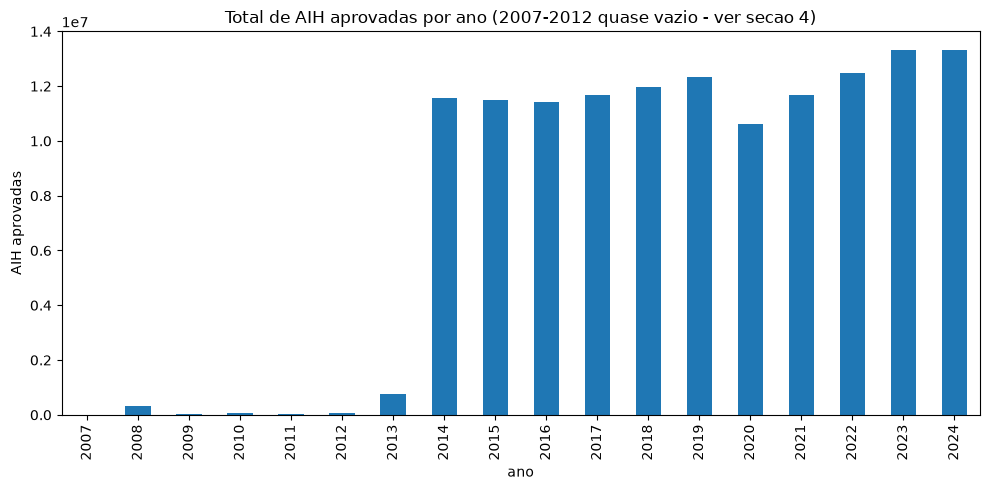

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))
aih[aih['procedimento_codigo'].notnull()].groupby('ano')['quantidade'].sum().sort_index().plot(kind='bar', ax=ax)
ax.set_title('Total de AIH aprovadas por ano (2007-2012 quase vazio - ver secao 4)')
ax.set_ylabel('AIH aprovadas')
plt.tight_layout()
plt.show()

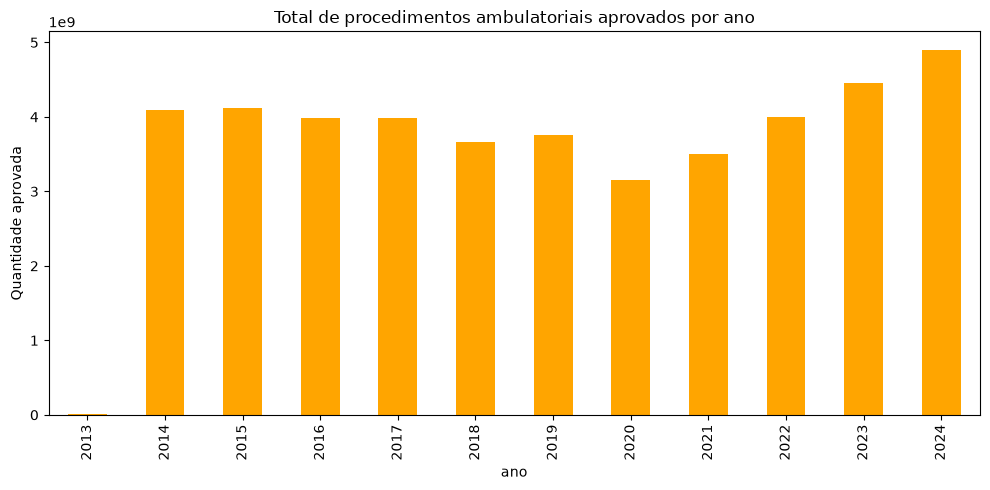

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))
qtd_amb[qtd_amb['procedimento_codigo'].notnull()].groupby('ano')['quantidade'].sum().sort_index().plot(kind='bar', ax=ax, color='orange')
ax.set_title('Total de procedimentos ambulatoriais aprovados por ano')
ax.set_ylabel('Quantidade aprovada')
plt.tight_layout()
plt.show()

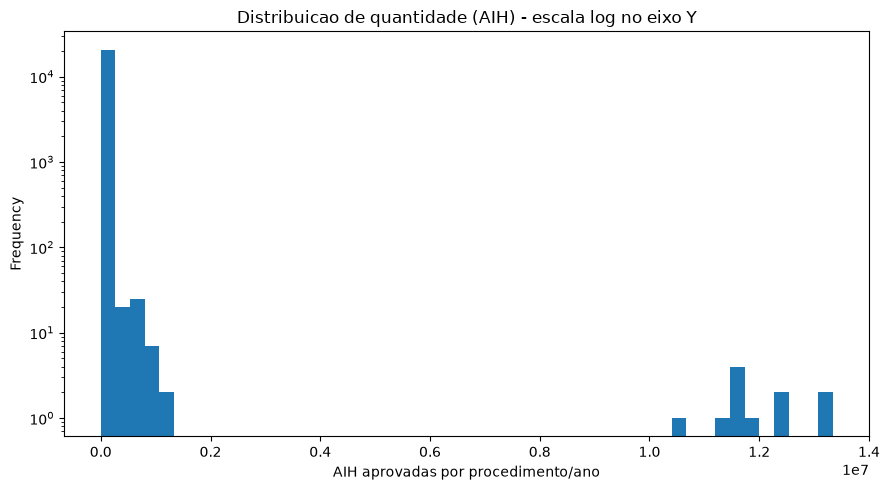

In [24]:
fig, ax = plt.subplots(figsize=(9, 5))
aih['quantidade'].dropna().plot(kind='hist', bins=50, ax=ax, log=True)
ax.set_title('Distribuicao de quantidade (AIH) - escala log no eixo Y')
ax.set_xlabel('AIH aprovadas por procedimento/ano')
plt.tight_layout()
plt.show()

## 12. Conclusões — transformações necessárias para a Silver

- **Nulos em `quantidade`:** remover, mas com a ressalva documentada na seção 4 — os nulos de 2007-2012 em `aih`/`valor_hosp` refletem um período em que a série mal existe (99%+ de nulos), diferente dos nulos normais de 2013 em diante (2-4%, mesmo patamar do IBGE/ISAPS). Vale considerar deixar isso explícito num comentário/coluna na Silver, ou pelo menos documentado, para quem for comparar totais entre 2007-2012 e 2014+ não achar que a série caiu — ela nunca existiu de fato antes disso.
- **Deduplicação:** nenhuma duplicata encontrada — mesma proteção estrutural das demais Silver.
- **Metadados:** `arquivo_origem`/`categoria`/`metrica`/`titulo`/`descricao_variavel`/`periodo_relatorio` são candidatos a uma tabela de metadados separada, no mesmo padrão do IBGE.
- **`procedimento_codigo`/`procedimento_nome`:** já vêm separados desde a Bronze; a linha `Total` (código nulo) deve ser mantida claramente identificável, não descartada nem confundida com um procedimento real.
- **Semântica do valor:** ao contrário da `renda` do IBGE, os valores em reais aqui **são somáveis** (são totais, não médias) — mas isso precisa ficar documentado no schema/texto da Silver mesmo assim, para não virar uma suposição não verificada da próxima pessoa que mexer nos dados.
- **Risco de junção hospitalar x ambulatorial:** `aih`/`valor_hosp` têm os mesmos procedimentos; `qtd_amb`/`valor_amb` não têm — um merge entre as duas tabelas de ambulatorial na Silver ou na Gold precisa decidir explicitamente como tratar os ~600 procedimentos que só existem em `qtd_amb`.
- **Validação de schema (`pandera`):** uma definição por tabela, seguindo o mesmo padrão do ISAPS e do IBGE.